In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the log file
with open("result_base8.log") as f:
    lines = f.readlines()

# Parse into structured records
records = []
current_depth = None
current_tasks = None
run_number = 0

for line in lines:
    line = line.strip()
    if line.startswith("DEPTH="):
        parts = line.split()
        current_depth = int(parts[0].split("=")[1])
        current_tasks = int(parts[1].split("=")[1])
        run_number = 0
    elif line.startswith("Run"):
        run_number += 1
    elif line and not line.startswith("Timeout"):
        try:
            runtime = float(line)
            records.append({
                "DEPTH": current_depth,
                "TASKS": current_tasks,
                "RUN": run_number,
                "RUNTIME": runtime
            })
        except ValueError:
            pass  # skip invalid floats (e.g. "nan")

# Convert to DataFrame
df = pd.DataFrame(records)

# Group and compute average and minimum runtime
summary = df.groupby(["DEPTH", "TASKS"]).agg(
    avg_runtime=("RUNTIME", "mean"),
    min_runtime=("RUNTIME", "min"),
    run_count=("RUNTIME", "count")
).reset_index()

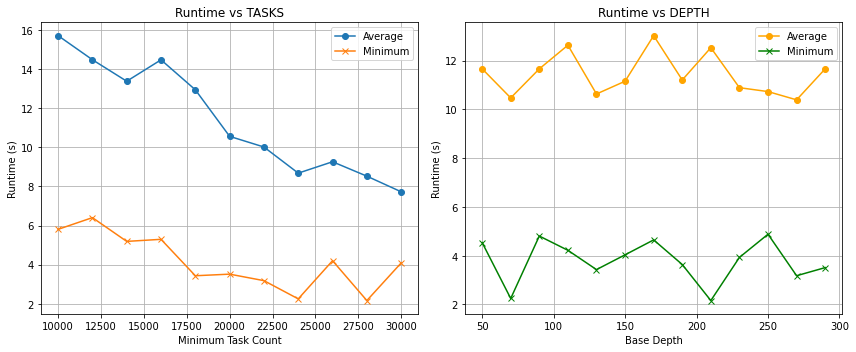

In [18]:
# Group by TASKS and DEPTH for average and minimum
task_avg = df.groupby("TASKS")["RUNTIME"].mean().reset_index()
task_min = df.groupby("TASKS")["RUNTIME"].min().reset_index()
depth_avg = df.groupby("DEPTH")["RUNTIME"].mean().reset_index()
depth_min = df.groupby("DEPTH")["RUNTIME"].min().reset_index()

# Plot
plt.figure(figsize=(12, 5))

# TASKS: Average and Min
plt.subplot(1, 2, 1)
plt.plot(task_avg["TASKS"], task_avg["RUNTIME"], label="Average", marker='o')
plt.plot(task_min["TASKS"], task_min["RUNTIME"], label="Minimum", marker='x')
plt.xlabel("Minimum Task Count")
plt.ylabel("Runtime (s)")
plt.title("Runtime vs TASKS")
plt.legend()
plt.grid(True)

# DEPTH: Average and Min
plt.subplot(1, 2, 2)
plt.plot(depth_avg["DEPTH"], depth_avg["RUNTIME"], label="Average", marker='o', color='orange')
plt.plot(depth_min["DEPTH"], depth_min["RUNTIME"], label="Minimum", marker='x', color='green')
plt.xlabel("Base Depth")
plt.ylabel("Runtime (s)")
plt.title("Runtime vs DEPTH")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
